# <b> Project II, Topic vi: Solar System Dashboard
###   &emsp;By: Siena Baez, Xander Graves, Carrie Ries, and Alexis Walker

# <b> Table of Contents  
## <b> &emsp;1: Imports and Prefaces
###  &emsp;&emsp;&emsp;Cells 1-#
## <b> &emsp;2: Planet Information and Setup


### <b> 1: Imports and Prefaces

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
from skyfield.api import load, wgs84
from skyfield import almanac
from datetime import datetime, timedelta 




In [2]:
eph = load('de440s.bsp')
#Using the de440s emphemeris file for the locations

sun = eph['sun']
earth = eph['earth']
pluto = eph['pluto barycenter']
mars = eph['mars barycenter']
jupiter = eph['jupiter barycenter']
saturn = eph['saturn barycenter']
uranus = eph['uranus barycenter']
venus = eph['venus barycenter']
mercury = eph['mercury barycenter']
#Grabbing the planets from the emphemeris and naming them 

ts = load.timescale()
#Skyfield's time system
t_variable = ts.now()
global t_variable

columbus_lat = 39.9612   
columbus_lon = -83.0003  
columbus_elev = 260      
#Location of Columbus, Ohio (observation point for our code)

columbus = earth + wgs84.latlon(columbus_lat, columbus_lon, elevation_m = columbus_elev)
#Creating the observer to call from 


##find the Moon phase, locations of planets and determine if they are in the sky during astronomical twilight 
# for moon: 
#   phase = almanac.moon_phase(eph, t) -> t is time, eph is the emphemeris 
# For moonrise: 
#   t, y = almanac.find_risings(observer, moon, t0, t1)
#   print('Moonrises (UTC):', t.utc_iso(' '))

#   t, y = almanac.find_settings(observer, moon, t0, t1)
#   print('Moonsets (UTC):', t.utc_iso(' ')) 
#  
# for other planets:
#   t, y = almanac.find_risings(observer, eph['Mars'], t0, t1)
# #print('Mars rises:', t.utc_iso(' '))

#   t, y = almanac.find_settings(observer, eph['Mars'], t0, t1)
#   print('Mars sets: ', t.utc_iso(' ')) 
#       eph['Mars'] is just mars in this case, and t0 and t1 are the timeframes 


### <b> 2: Planet Information and Setup

In [ ]:
class planet:
    def find_alt_az():
        

    def observation_from_columbus(self, ):
        astrometric = columbus.at(t_now).observe(self)
        apparent = astrometric.apparent()
        alt, az, distance = apparent.altaz(pressure_mbar=1010)
        


SyntaxError: expected ':' (1091242198.py, line 1)

Computed Mars position as seen from Earth
Mars on 2026-03-01T00:00:00Z:
  Right Ascension: 22h 03m 42.99s
  Declination: -13deg 03' 42.1"
  Distance: 2.341280 AU
Position comparison:
  Astrometric: RA=22.061941h, Dec=-13.061692°
  Apparent:    RA=22.061578h, Dec=-13.063635°
  Difference:  ΔRA=-1.31 arcsec
Computed 31 positions from March 1, 2026 to April 1, 2026
Position on March 1, 2026: RA=22.06h, Dec=-13.06°
Position on April 1, 2026: RA=23.54h, Dec=-4.15°


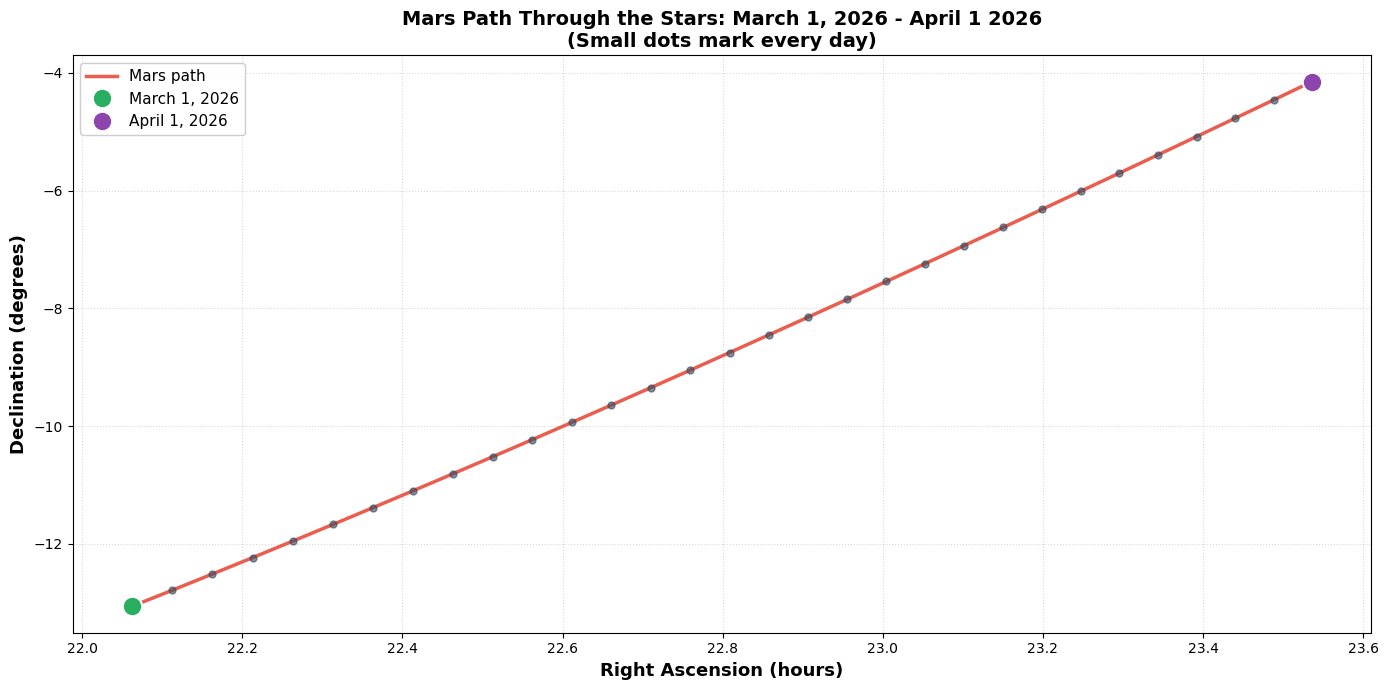

In [8]:
#Practice Cell...AKA I have no idea what is going on lol!!
t = ts.utc(2026, 3, 1, 0, 0)

global t 

astrometric = earth.at(t).observe(mars)
print("Computed Mars position as seen from Earth")

ra, dec, distance = astrometric.radec()
print(f"Mars on {t.utc_iso()}:")
print(f"  Right Ascension: {ra}")
print(f"  Declination: {dec}")
print(f"  Distance: {distance.au:.6f} AU")

apparent = astrometric.apparent()
ra_app, dec_app, dist_app = apparent.radec()

print(f"Position comparison:")
print(f"  Astrometric: RA={ra.hours:.6f}h, Dec={dec.degrees:.6f}°")
print(f"  Apparent:    RA={ra_app.hours:.6f}h, Dec={dec_app.degrees:.6f}°")
print(f"  Difference:  ΔRA={(ra_app.hours - ra.hours) * 3600:.2f} arcsec")

days = np.arange(0, 31) 
times_year = ts.utc(2026, 3, 1 + days)

positions = earth.at(times_year).observe(mars)
ra_year, dec_year, dist_year = positions.radec()

print(f"Computed {len(ra_year.hours)} positions from March 1, 2026 to April 1, 2026")
print(f"Position on March 1, 2026: RA={ra_year.hours[0]:.2f}h, Dec={dec_year.degrees[0]:.2f}°")
print(f"Position on April 1, 2026: RA={ra_year.hours[-1]:.2f}h, Dec={dec_year.degrees[-1]:.2f}°")

ra_hours = ra_year.hours.copy()
ra_diff = np.diff(ra_hours, prepend=ra_hours[0])

# Identify where wraps occur (jumps > 12h or < -12h)
wrap_up = ra_diff > 12   # Jumped from ~23h to ~0h, need to add 24
wrap_down = ra_diff < -12  # Jumped from ~0h to ~23h, need to subtract 24

shifts = np.cumsum(wrap_up.astype(int) * 24 - wrap_down.astype(int) * 24)
ra_hours = ra_hours + shifts

plt.figure(figsize=(14, 7))
plt.plot(ra_hours, dec_year.degrees, color='#E74C3C', linewidth=2.5, 
         label='Mars path', alpha=0.9)
plt.plot(ra_hours[0], dec_year.degrees[0], 'o', color='#27AE60', 
         markersize=14, label='March 1, 2026', zorder=5, markeredgecolor='white', markeredgewidth=1.5)
plt.plot(ra_hours[-1], dec_year.degrees[-1], 'o', color='#8E44AD', 
         markersize=14, label='April 1, 2026', zorder=5, markeredgecolor='white', markeredgewidth=1.5)

marker_indices = np.arange(0, len(days), 1)
plt.plot(ra_hours[marker_indices], dec_year.degrees[marker_indices], 'o', 
         color='#34495E', markersize=5, alpha=0.6)

plt.xlabel('Right Ascension (hours)', fontsize=13, fontweight='bold')
plt.ylabel('Declination (degrees)', fontsize=13, fontweight='bold')
plt.title('Mars Path Through the Stars: March 1, 2026 - April 1 2026\n(Small dots mark every day)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.tight_layout()
plt.show()